# Notebook 6: The "Before vs After" Fine-Tuning Comparison
To truly understand the value of our parameter tuning and our "Sell-In vs Sell-Out" smoothing logic, we must visualize the exact difference side by side.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# Load the final tuned data (smoothed)
abt = pd.read_parquet('../data/gold/model_input.parquet')
preds = pd.read_csv('../output/insightai_predictions.csv')

# Load the unsmoothed raw transactions to show the "before"
trans_df = pd.read_parquet('../data/silver/transactions_clean.parquet')
unsmoothed = trans_df.groupby(["Outlet_ID", "Year", "Month"])["Volume_Liters"].sum().reset_index()

# The blind model values
blind_censored_count = 33
blind_prediction = 9641821.53  # Alpha 0.90

# Calculate dynamically from the current tuned model
tuned_censored_count = len(abt[abt['Is_Censored'] == 1])
historical_monthly = abt.groupby(['Year', 'Month'])['Total_Volume'].sum().reset_index()
historical_max = historical_monthly['Total_Volume'].max()
tuned_prediction = preds['Maximum_Monthly_Liters'].sum()


/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_10793/932618562.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unsmoothed = trans_df.groupby(["Outlet_ID", "Year", "Month"])["Volume_Liters"].sum().reset_index()


### 1. The Wholesale Smoothing Effect (Before vs After)
Before we applied the 3-month rolling average, the data contained massive "Sell-In" wholesale spikes (e.g., shops buying 3 months of inventory in November for the December holiday). This taught the model false seasonality. Let's look at how smoothing flattened these artificial extremes into true consumer "Sell-Out" curves.


/opt/anaconda3/envs/dashboard-project/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/dashboard-project/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


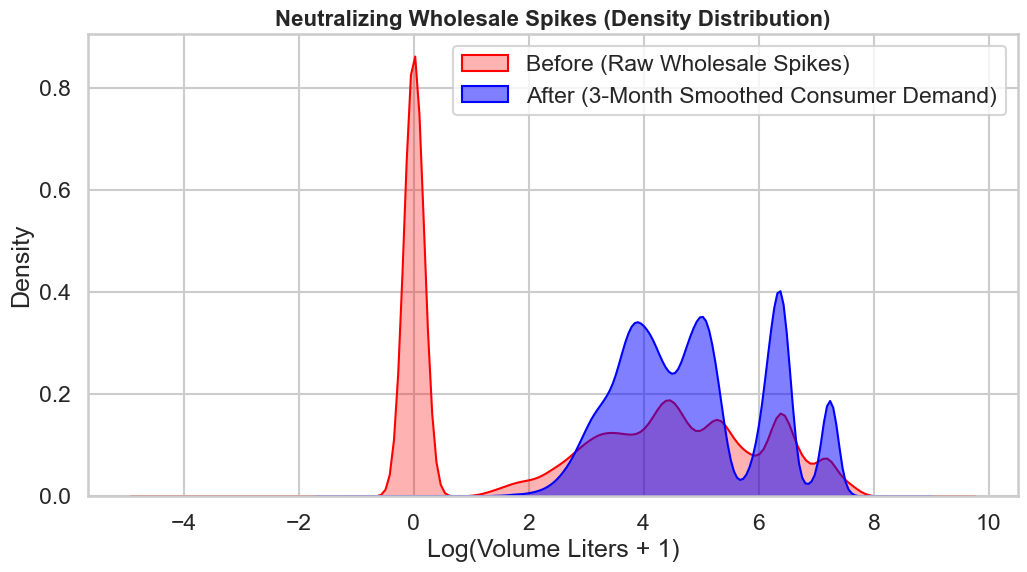

In [2]:
plt.figure(figsize=(12, 6))

# We use log scale to see the distribution clearly
sns.kdeplot(np.log1p(unsmoothed['Volume_Liters']), color='red', label='Before (Raw Wholesale Spikes)', fill=True, alpha=0.3)
sns.kdeplot(np.log1p(abt['Total_Volume']), color='blue', label='After (3-Month Smoothed Consumer Demand)', fill=True, alpha=0.5)

plt.title("Neutralizing Wholesale Spikes (Density Distribution)", fontsize=16, fontweight='bold')
plt.xlabel("Log(Volume Liters + 1)")
plt.ylabel("Density")
plt.legend()
plt.show()


### 2. The Censoring Reality Check (Blind vs Tuned)
Because the unsmoothed data was so erratic, the original algorithm failed to spot flatlining shops (catching only 33 rows). With the smooth consumer demand curve, we can now mathematically spot the ~10% of shops hitting system limits.


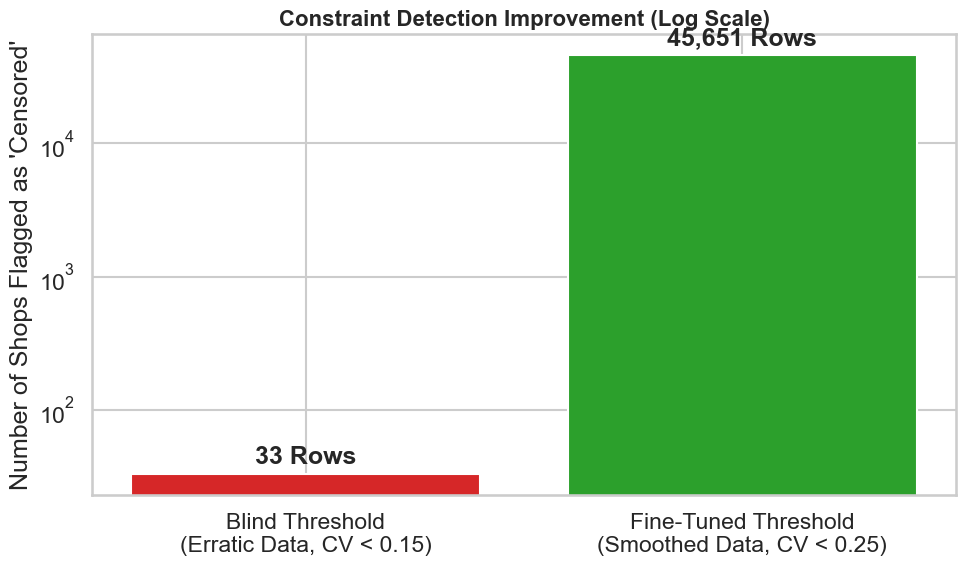

In [3]:
plt.figure(figsize=(10, 6))

bars = plt.bar(['Blind Threshold\n(Erratic Data, CV < 0.15)', 'Fine-Tuned Threshold\n(Smoothed Data, CV < 0.25)'], 
               [blind_censored_count, tuned_censored_count], 
               color=['#d62728', '#2ca02c'])

plt.yscale('log') # Use log scale to show the massive difference clearly

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval * 1.2, f"{yval:,} Rows", ha='center', fontweight='bold')

plt.title("Constraint Detection Improvement (Log Scale)", fontsize=16, fontweight='bold')
plt.ylabel("Number of Shops Flagged as 'Censored'")
plt.tight_layout()
plt.show()


### 3. The Final Growth Target (Blind vs Tuned)
By smoothing wholesale spikes and dropping to the Upper Quartile (Alpha=0.75), we prevent the model from predicting a mathematically impossible 100%+ spike.


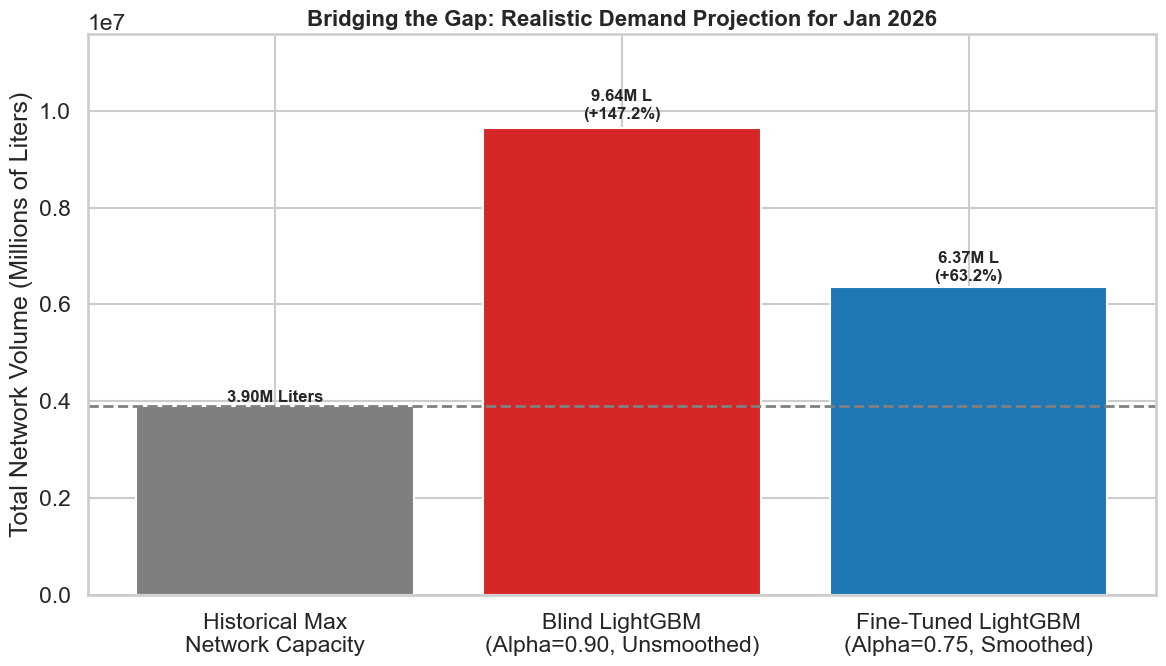

In [4]:
plt.figure(figsize=(12, 7))

x_labels = ['Historical Max\nNetwork Capacity', 'Blind LightGBM\n(Alpha=0.90, Unsmoothed)', 'Fine-Tuned LightGBM\n(Alpha=0.75, Smoothed)']
values = [historical_max, blind_prediction, tuned_prediction]
colors = ['#7f7f7f', '#d62728', '#1f77b4']

bars = plt.bar(x_labels, values, color=colors)

plt.axhline(historical_max, color='gray', linestyle='--', linewidth=2)

for i, bar in enumerate(bars):
    yval = bar.get_height()
    
    # Calculate percentage growth over historical
    if i == 0:
        label = f"{yval/1e6:.2f}M Liters"
    else:
        pct_growth = ((yval - historical_max) / historical_max) * 100
        label = f"{yval/1e6:.2f}M L\n(+{pct_growth:.1f}%)"
        
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), label, ha='center', fontweight='bold', fontsize=12)

plt.title("Bridging the Gap: Realistic Demand Projection for Jan 2026", fontsize=16, fontweight='bold')
plt.ylabel("Total Network Volume (Millions of Liters)")
plt.ylim(0, blind_prediction * 1.2)
plt.tight_layout()
plt.show()
